# MHIST Data Exploration

Explore the dataset, labels, and class distribution.

In [ ]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

print("Libraries imported successfully!")

Libraries imported successfully!


In [15]:
# Define paths to the MHIST dataset

annotations_path = "../data/raw/annotations.csv"
images_path = r"C:\Users\DARPAN\Downloads\images\images"

# Load the annotation file
df = pd.read_csv(annotations_path)

print("Annotations loaded successfully!")
print("Dataset shape:", df.shape)

print("Number of rows in the dataset:", len(df))
print("\nColumn names:")
print(df.columns.tolist())
print("\nMissing values:", df.isnull().sum().sum())

Annotations loaded successfully!
Dataset shape: (3152, 4)
Number of rows in the dataset: 3152

Column names:
['Image Name', 'Majority Vote Label', 'Number of Annotators who Selected SSA (Out of 7)', 'Partition']

Missing values: 0


In [16]:
image_files=[]
for filename in os.listdir(images_path):
    if filename.endswith((".jpg", ".png", ".jpeg")):
        image_files.append(filename)

print("Number of image files found:", len(image_files))

Number of image files found: 3152


In [17]:
print("Images:", len(image_files))
print("Annotations:",len(df))

Images: 3152
Annotations: 3152


In [23]:
print(df.columns.tolist())
class_counts=df["Majority Vote Label"].value_counts()
print("Class distribution:", class_counts)
partition_counts=df["Partition"].value_counts()
print("Partition distribution:", partition_counts)

['Image Name', 'Majority Vote Label', 'Number of Annotators who Selected SSA (Out of 7)', 'Partition']
Class distribution: Majority Vote Label
HP     2162
SSA     990
Name: count, dtype: int64
Partition distribution: Partition
train    2175
test      977
Name: count, dtype: int64


In [24]:
partition_label_counts=pd.crosstab(df["Partition"], df["Majority Vote Label"])
print(partition_label_counts)
partition_label_percentage = pd.crosstab(df["Partition"], df["Majority Vote Label"], normalize='index') * 100
print("\nPercentage distribution of labels within each partition:")
print(partition_label_percentage.round(2))

Majority Vote Label    HP  SSA
Partition                     
test                  617  360
train                1545  630

Percentage distribution of labels within each partition:
Majority Vote Label     HP    SSA
Partition                        
test                 63.15  36.85
train                71.03  28.97


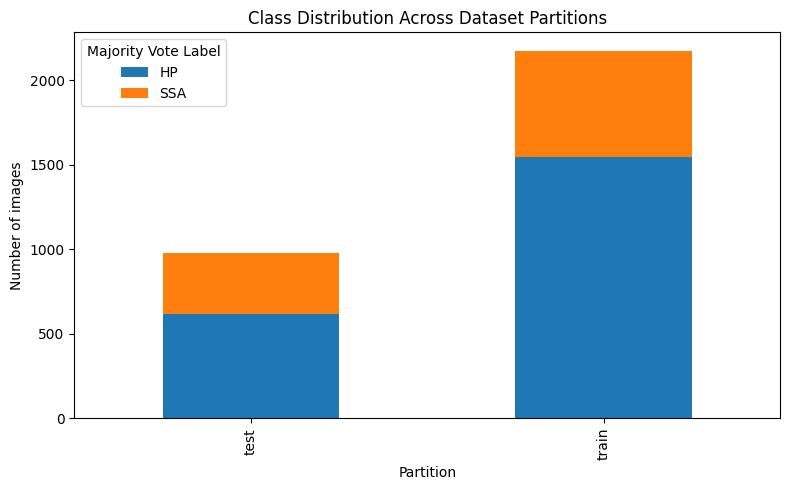

Number of Annotators who Selected SSA (Out of 7)
0    723
1    705
2    426
3    308
4    216
5    168
6    250
7    356
Name: count, dtype: int64


In [34]:
import matplotlib.pyplot as plt
partition_label_counts.plot(kind='bar',stacked=True, figsize=(8, 5), title='Class Distribution Across Dataset Partitions',xlabel='Partition',ylabel='Number of images')
plt.legend(title='Majority Vote Label')
plt.tight_layout()
plt.show()
agreement_counts = df["Number of Annotators who Selected SSA (Out of 7)"].value_counts().sort_index()
print(agreement_counts)


In [ ]:
# Checking image dimensions
dimensions=[]
for filename in image_files:
    path = os.path.join(images_path, filename)
    try:
        with Image.open(path) as img:
            dimensions.append({"filename": filename, "width": img.width, "height": img.height,"mode": img.mode})
    except Exception as e:
        print(f"Error opening {filename}: {e}")
dimensions_df=pd.DataFrame(dimensions)
display(dimensions_df.head())


,filename,width,height,mode
0,MHIST_aaa.png,224,224,RGB
1,MHIST_aab.png,224,224,RGB
2,MHIST_aac.png,224,224,RGB
3,MHIST_aad.png,224,224,RGB
4,MHIST_aae.png,224,224,RGB


In [37]:
#Dimension statistics
print(dimensions_df[["width", "height"]].describe())
print(dimensions_df[["width", "height"]].value_counts())

        width  height
count  3152.0  3152.0
mean    224.0   224.0
std       0.0     0.0
min     224.0   224.0
25%     224.0   224.0
50%     224.0   224.0
75%     224.0   224.0
max     224.0   224.0
width  height
224    224       3152
Name: count, dtype: int64


In [38]:
#checking corrupted images
corrupted_images=[]
for filename in image_files:
    path = os.path.join(images_path, filename)
    try:
        with Image.open(path) as img:
            img.verify()
    except Exception as e:
        corrupted_images.append(filename)
        print("Corrupted images:",len(corrupted_images))
print(corrupted_images)

[]


In [41]:
#duplicate detection 
import hashlib
hashes={}
for filename in image_files:
    path=os.path.join(images_path,filename)
    with open(path,"rb") as f:
        file_hash=hashlib.md5(f.read()).hexdigest()
        hashes.setdefault(file_hash,[]).append(filename)
duplicates = {
    h: files
    for h, files in hashes.items()
    if len(files) > 1
}

print(
    "Duplicate groups:",
    len(duplicates)
)

for h, files in duplicates.items():

    print(files)
    

Duplicate groups: 0


In [42]:
# Check whether every annotated image exists

missing_images = []

for name in df["Image Name"]:
    image_path = os.path.join(images_path, name)
    
    if not os.path.exists(image_path):
        missing_images.append(name)

print("Total annotated images:", len(df))
print("Missing images:", len(missing_images))

if len(missing_images) > 0:
    print("\nMissing image names:")
    print(missing_images[:20])
else:
    print("All annotated images are present! ✅")

Total annotated images: 3152
Missing images: 0
All annotated images are present! ✅


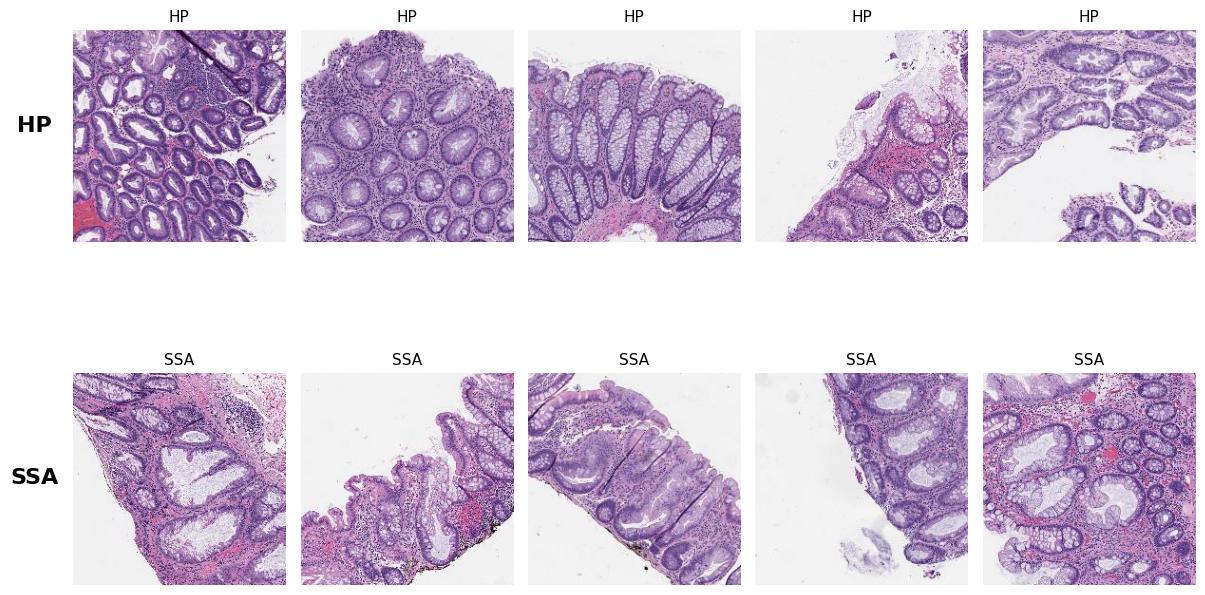

In [47]:
hp_samples = df[df["Majority Vote Label"] == "HP"].sample(5, random_state=42)

ssa_samples = df[df["Majority Vote Label"] == "SSA"].sample(5, random_state=42)

sample_df = pd.concat([hp_samples,ssa_samples])

plt.figure(figsize=(12, 8))

for i, (_, row) in enumerate(sample_df.iterrows()):

    filename = row["Image Name"]

    path = os.path.join(images_path,filename)

    img = Image.open(path)

    plt.subplot(2, 5, i + 1)

    plt.imshow(img)

    plt.title(row["Majority Vote Label"], fontsize=11)

    plt.axis("off")

# Row labels
plt.figtext(0.02, 0.72,"HP",fontsize=16,fontweight="bold",ha="center")
plt.figtext(0.02, 0.28,"SSA",fontsize=16,fontweight="bold",ha="center")
plt.tight_layout(rect=[0.04, 0, 1, 1])
plt.show()

In [51]:
import numpy as np

sample_names = df["Image Name"].sample(5, random_state=42)

for name in sample_names:
    image_path = os.path.join(images_path, name)
    
    img = np.array(Image.open(image_path))
    
    print(
        name,
        "→ min:", img.min(),
        "max:", img.max(),
        "mean:", round(img.mean(), 2)
    )

MHIST_blw.png → min: 0 max: 255 mean: 172.09
MHIST_dou.png → min: 0 max: 255 mean: 177.7
MHIST_eoz.png → min: 0 max: 255 mean: 163.41
MHIST_cor.png → min: 0 max: 255 mean: 183.68
MHIST_ecj.png → min: 0 max: 255 mean: 191.41
